# Learn TSA Basics

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Import the created database
from Descriptive import Descriptive

In [3]:
Obj = Descriptive()

In [4]:
# import TSA library and assign input variables
from nsepy import get_history as gh
import datetime as dt
import yfinance as yf
stock_symbol = "RELIANCE.NS"
start = dt.datetime(2021,6,1)
end = dt.datetime(2022,1,5)
Stock_data = yf.download(stock_symbol, start=start, end=end)

[*********************100%***********************]  1 of 1 completed


In [5]:
Stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 150 entries, 2021-06-01 to 2022-01-04
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   150 non-null    float64
 1   (High, RELIANCE.NS)    150 non-null    float64
 2   (Low, RELIANCE.NS)     150 non-null    float64
 3   (Open, RELIANCE.NS)    150 non-null    float64
 4   (Volume, RELIANCE.NS)  150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 7.0 KB


In [6]:
Stock_data

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2021-06-01,978.920959,993.860450,968.810795,977.612032,28013832
2021-06-02,993.521912,997.245502,973.549903,973.549903,24630162
2021-06-03,997.313232,1015.524983,991.197542,1002.435946,23974257
2021-06-04,988.669983,1000.382342,985.849055,999.637624,14468646
2021-06-07,1005.324524,1011.914169,986.187547,993.860425,16336573
...,...,...,...,...,...
2021-12-29,1088.135376,1095.608521,1078.895776,1082.926817,15425312
2021-12-30,1068.478760,1089.245071,1062.364390,1087.003127,29333171


In [7]:
Low = Stock_data["Low"]

In [8]:
Dataset = Stock_data
Quan,Qual = Obj.segreQuanQual(Dataset)

The Quantitative Data: [('Close', 'RELIANCE.NS'), ('High', 'RELIANCE.NS'), ('Low', 'RELIANCE.NS'), ('Open', 'RELIANCE.NS'), ('Volume', 'RELIANCE.NS')]
The Qualtitative Data []


In [9]:
Des_data = Obj.descriptive_Analysis(Dataset,Quan)
Des_data

,"(Close, RELIANCE.NS)","(High, RELIANCE.NS)","(Low, RELIANCE.NS)","(Open, RELIANCE.NS)","(Volume, RELIANCE.NS)"
Null_count,0,0,0,0,0
NonNull_count,150,150,150,150,150
Total_Count,150,150,150,150,150
Mean,1057.407557,1069.158085,1047.010469,1059.003781,14584981.813333
Median,1072.113342,1084.90828,1062.930499,1073.890937,12087939.0
Mode,944.786804,932.105009,913.195667,930.293307,1705656
Std,85.694091,87.65443,83.742214,86.078635,9640997.620994
Min,921.823853,932.105009,913.195667,930.293307,1705656.0
Q1:25%,979.032501,989.89739,968.11686,975.922,9784558.0
Q2:50%,1072.113342,1084.90828,1062.930499,1073.890937,12087939.0


In [11]:
Des_data["Low", "RELIANCE.NS"]

Null_count                 0
NonNull_count            150
Total_Count              150
Mean             1047.010469
Median           1062.930499
Mode              913.195667
Std                83.742214
Min               913.195667
Q1:25%             968.11686
Q2:50%           1062.930499
Q3:75%           1111.828506
Q4:100%          1226.501675
IQR               143.711646
1.5Rule           215.567469
Lesser            752.549391
Greater          1327.395975
Name: (Low, RELIANCE.NS), dtype: object

In [15]:
Des_data["High", "RELIANCE.NS"]

Null_count                 0
NonNull_count            150
Total_Count              150
Mean             1069.158085
Median            1084.90828
Mode              932.105009
Std                 87.65443
Min               932.105009
Q1:25%             989.89739
Q2:50%            1084.90828
Q3:75%           1132.176049
Q4:100%           1246.13563
IQR               142.278659
1.5Rule           213.417988
Lesser            776.479402
Greater          1345.594037
Name: (High, RELIANCE.NS), dtype: object

In [12]:
import numpy as np

In [13]:
np.percentile(Dataset["Low"], 99)

1218.0743274386814

In [16]:
np.percentile(Dataset["High"], 80)

1146.2627973391325

In [17]:
def get_pdf_prbability(Dataset, startrange, endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    ax = sns.distplot(Dataset, kde = True, kde_kws = {'color':'blue'}, color='Green')
    pyplot.axvline(startrange, color='Red')
    pyplot.axvline(endrange, color='Red')
    # Generation of sample
    sample = Dataset
    #Calculation of parameters
    sample_mean = sample.mean()
    sample_std = sample.std()
    print('Mean = %.3f, Standard Deviation = %.3f' % (sample_mean, sample_std))
    #Define the distribution
    Dist = norm(sample_mean, sample_std)
    #Determination of sample probabilities for a range of outcomes
    values = [value for value in range (startrange, endrange)]
    probabilities = [Dist.pdf(value) for value in values]
    Prob = sum(probabilities)
    print("The area between range ({},{}):{}".format(startrange, endrange, sum(probabilities)))
    return Prob

Mean = 1047.010, Standard Deviation = 83.742
The area between range (1199,1220):[0.01551501]


array([0.01551501])

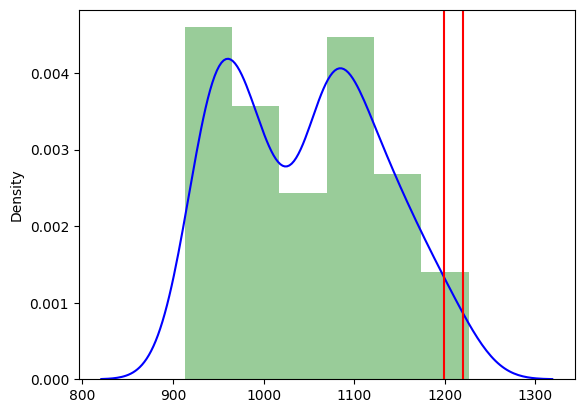

In [18]:
get_pdf_prbability(Dataset["Low"], 1199, 1220)

In [26]:
def FreqTable(ColName, Dataset):
    import pandas as pd
    Frq = pd.DataFrame()
    Frq["Unique_Values"] = Dataset[ColName].value_counts().index
    Frq["Frequency"] = Dataset[ColName].value_counts().values
    Frq["Relative_Frq"] = Dataset[ColName].value_counts().values/len(Dataset[ColName])*100
    Frq["Cumulative"] = Frq["Relative_Frq"].cumsum()
    return Frq

In [30]:
FreqTable("High", Dataset)

ValueError: Cannot set a frame with no defined index and a value that cannot be converted to a Series